# Inteligencia Artificial 2026-2
##  Autoencoders
> objetivo: este notebook guía paso a paso la construcción de un autoencoder (ae) para denoising y un variational autoencoder (vae) simple. Se incluyen ejercicios con secciones de código por completar.


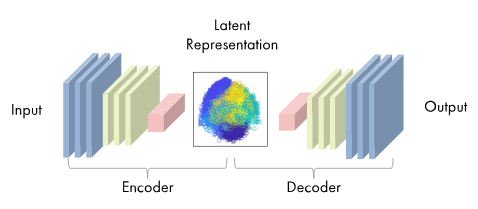

## Preparación del entorno
En esta sección se importan librerías y se fija una semilla para reproducibilidad.


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)
print("versiones:")
print("numpy:", np.__version__)
print("tensorflow:", tf.__version__)

versiones:
numpy: 2.4.2
tensorflow: 2.20.0


## Configuración de acelerador (GPU si existe)
Esta sección configura TensorFlow para usar GPU automáticamente cuando esté disponible.

- Si hay GPU: activa `memory_growth`, mixed precision (`float16`) y XLA.
- Si no hay GPU: mantiene ejecución en CPU con `float32` y muestra diagnóstico.

Ejecuta esta celda antes de entrenar modelos.

In [9]:
import platform
import shutil
import subprocess
import tensorflow as tf
from tensorflow.keras import mixed_precision


def setup_accelerator(enable_mixed_precision=True, enable_xla=False, force_cpu=False):
    gpus = tf.config.list_physical_devices("GPU")

    # Si force_cpu=True, desactivamos GPU antes de inicializar kernels.
    if force_cpu and gpus:
        try:
            tf.config.set_visible_devices([], "GPU")
            gpus = []
        except Exception as ex:
            print(f"No se pudo desactivar GPU explícitamente: {ex}")

    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as ex:
            print(f"No se pudo activar memory growth en {gpu}: {ex}")

    if gpus and enable_mixed_precision:
        mixed_precision.set_global_policy("mixed_float16")
    else:
        mixed_precision.set_global_policy("float32")

    if enable_xla:
        tf.config.optimizer.set_jit(True)

    print("TensorFlow:", tf.__version__)
    print("Sistema:", platform.system(), platform.release())
    print("GPUs detectadas por TensorFlow:", gpus)
    print("Precision policy:", mixed_precision.global_policy())

    nvidia_smi = shutil.which("nvidia-smi")
    if nvidia_smi:
        print("\nSalida corta de nvidia-smi:")
        try:
            out = subprocess.check_output(
                [nvidia_smi, "--query-gpu=name,driver_version,memory.total", "--format=csv,noheader"],
                text=True,
                stderr=subprocess.STDOUT,
            )
            print(out.strip())
        except Exception as ex:
            print(f"No se pudo ejecutar nvidia-smi: {ex}")
    else:
        print("\nnvidia-smi no está disponible en PATH.")

    return gpus


# En esta sesión forzamos CPU para evitar errores CUDA en la RTX 5060 Ti con TF estable actual.
FORCE_CPU = True
GPUS = setup_accelerator(enable_mixed_precision=True, enable_xla=False, force_cpu=FORCE_CPU)
USE_GPU = len(GPUS) > 0
print("USE_GPU:", USE_GPU)
if not USE_GPU:
    print("\nModo CPU activado para estabilidad del notebook.")

TensorFlow: 2.20.0
Sistema: Linux 6.6.87.2-microsoft-standard-WSL2
GPUs detectadas por TensorFlow: []
Precision policy: <DTypePolicy "float32">

Salida corta de nvidia-smi:
NVIDIA GeForce RTX 5060 Ti, 576.88, 16311 MiB
USE_GPU: False

Modo CPU activado para estabilidad del notebook.


## Carga y preprocesamiento de datos
Usaremos **fashion-mnist** (28×28 en escala de grises). Normalizaremos a [0, 1] y añadiremos ruido gaussiano para el denoising.


In [10]:
(x_train, _), (x_test, _) = keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train[..., None]
x_test = x_test[..., None]
print("formas:", x_train.shape, x_test.shape)

formas: (60000, 28, 28, 1) (10000, 28, 28, 1)


### Función para añadir ruido gaussiano
Esta función devuelve una versión ruidosa recortada al rango [0, 1]. Modifica `sigma` para controlar la intensidad del ruido.


In [11]:
def add_noise(x, sigma=0.1 ):
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=sigma)
    x_noisy = tf.clip_by_value(x + noise, 0.0, 1.0)
    return x_noisy

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

print("ejemplo de valores:", float(tf.reduce_min(x_train_noisy)), float(tf.reduce_max(x_train_noisy)))

ejemplo de valores: 0.0 1.0


### Augmentación geométrica para robustez
Aplicamos pequeñas variaciones de geometría para que el autoencoder no dependa solo de posición/orientación:

- espejo horizontal (`RandomFlip`)
- rotación leve (`RandomRotation`)
- traslación leve (`RandomTranslation`)

Importante: en denoising, la transformación debe aplicarse de forma consistente al objetivo limpio y luego añadir ruido blanco a la entrada.

In [12]:
# Capas de augmentación geométrica (suaves para no deformar demasiado la semántica)
# Si USE_GPU es False (o la GPU no es operativa), forzamos esta parte en CPU para estabilidad.
AUG_DEVICE = "/GPU:0" if globals().get("USE_GPU", False) else "/CPU:0"

with tf.device(AUG_DEVICE):
    geom_augment = keras.Sequential(
        [
            layers.RandomFlip(mode="horizontal"),
            layers.RandomRotation(factor=0.08, fill_mode="reflect"),
            layers.RandomTranslation(height_factor=0.08, width_factor=0.08, fill_mode="reflect"),
        ],
        name="geom_augment",
    )


def make_denoising_datasets(
    x_train_clean,
    x_test_clean,
    batch_size=128,
    noise_sigma=0.1,
    use_augmentation=True,
):
    def train_map(clean):
        clean = tf.cast(clean, tf.float32)
        if use_augmentation:
            clean = geom_augment(clean, training=True)
        noisy = add_noise(clean, sigma=noise_sigma)
        return noisy, clean

    def val_map(clean):
        clean = tf.cast(clean, tf.float32)
        noisy = add_noise(clean, sigma=noise_sigma)
        return noisy, clean

    ds_train = (
        tf.data.Dataset.from_tensor_slices(x_train_clean)
        .shuffle(10000)
        .map(train_map, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

    ds_val = (
        tf.data.Dataset.from_tensor_slices(x_test_clean)
        .map(val_map, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

    return ds_train, ds_val


USE_AUGMENTATION = True
BATCH_SIZE = 128
NOISE_SIGMA = 0.1

ds_train, ds_val = make_denoising_datasets(
    x_train,
    x_test,
    batch_size=BATCH_SIZE,
    noise_sigma=NOISE_SIGMA,
    use_augmentation=USE_AUGMENTATION,
)

print("AUG_DEVICE:", AUG_DEVICE)
print("Datasets listos:", ds_train, ds_val)

AUG_DEVICE: /CPU:0
Datasets listos: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None))> <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None))>


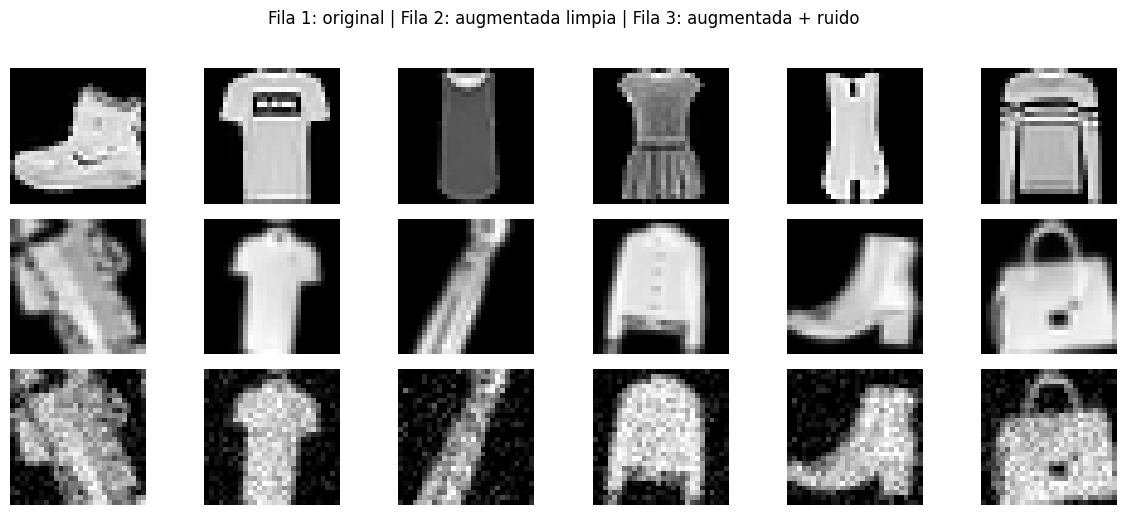

In [13]:
# Visualización: original vs augmentada vs augmentada+ruido
sample_batch = next(iter(ds_train.take(1)))
noisy_batch, clean_aug_batch = sample_batch

n = 6
plt.figure(figsize=(12, 5))
for i in range(n):
    # original limpia
    plt.subplot(3, n, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.axis("off")

    # limpia augmentada (objetivo)
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(clean_aug_batch[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")

    # entrada augmentada + ruido
    plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(noisy_batch[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Fila 1: original | Fila 2: augmentada limpia | Fila 3: augmentada + ruido", y=1.02)
plt.tight_layout()
plt.show()

### Visualización rápida: originales vs ruidosas
Se muestra una fila con cuatro pares (original, ruidosa).


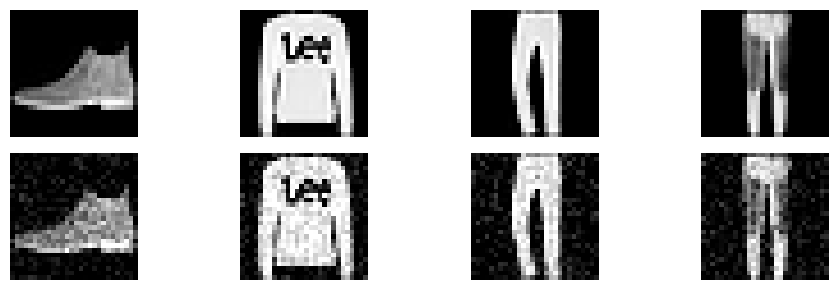

In [14]:
plt.figure(figsize=(10, 3))
n = 4
for i in range(n):
    # original
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    # ruidosa
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Autoencoder de denoising (ae)
A continuación definimos un ae conv. Entrenaremos para mapear una imagen **ruidosa** a su versión **limpia**.


In [15]:
latent_dim = 64  # puedes cambiar el tamaño

# encoder
inputs = keras.Input(shape=(28, 28, 1), name="entrada")
e = layers.Conv2D(64, 3, activation="relu", padding="same")(inputs)
e = layers.MaxPooling2D()(e)
e = layers.Conv2D(128, 3, activation="relu", padding="same")(e)
e = layers.MaxPooling2D()(e)
e = layers.Flatten()(e)
z = layers.Dense(latent_dim, activation="relu", name="latente")(e)

# decoder
d = layers.Dense(7*7*64, activation="relu")(z)
d = layers.Reshape((7, 7, 64))(d)
d = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(d)
d = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(d)
outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same", name="salida")(d)

ae = keras.Model(inputs, outputs, name="ae_denoising")
ae.summary()

Model: "ae_denoising"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latente (Dense)                 │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3136)           │       203,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Conv2D)                 │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 735,489 (2.81 MB)

 Trainable params: 735,489 (2.81 MB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento del ae
Usamos `binary_crossentropy` con datos en [0, 1] y adam con `lr=1e-3`.


Epoch 1/15


2026-04-21 11:10:24.220135: I external/local_xla/xla/service/service.cc:163] XLA service 0x74db2800eae0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-04-21 11:10:24.220170: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2026-04-21 11:10:24.369939: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776791424.888529   18776 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 207ms/step - loss: 0.3787 - val_loss: 0.3112
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 96s 204ms/step - loss: 0.3271 - val_loss: 0.2991
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 96s 205ms/step - loss: 0.3213 - val_loss: 0.2941
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 96s 205ms/step - loss: 0.3182 - val_loss: 0.2909
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 96s 204ms/step - loss: 0.3166 - val_loss: 0.2877
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 96s 205ms/step - loss: 0.3155 - val_loss: 0.2877
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 96s 205ms/step - loss: 0.3148 - val_loss: 0.2863
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 97s 207ms/step - loss: 0.3142 - val_loss: 0.2850
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 97s 208ms/step - loss: 0.3136 - val_loss: 0.2841
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 97s 207ms/step - loss: 0.3134 - val_loss: 0.2838
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 96s 205ms/step - loss: 0.3127 - val_loss: 0.2822
Epoch 12/15
469/469 ━━━━━━━━━━

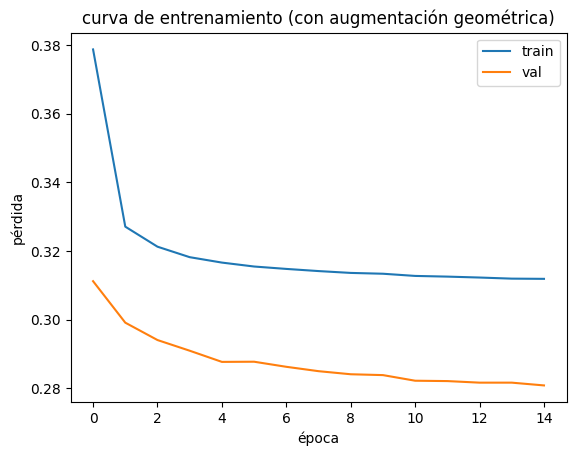

In [16]:
ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")

hist = ae.fit(
    ds_train,
    validation_data=ds_val,
    epochs=15,
    verbose=1,
)

plt.figure()
plt.plot(hist.history["loss"], label="train")
plt.plot(hist.history["val_loss"], label="val")
plt.xlabel("época")
plt.ylabel("pérdida")
plt.legend()
plt.title("curva de entrenamiento (con augmentación geométrica)")
plt.show()

In [17]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Evaluación del ae: reconstrucciones y métricas
Aquí comparamos ruidosa → reconstruida vs original. Además calculamos mse y ssim.


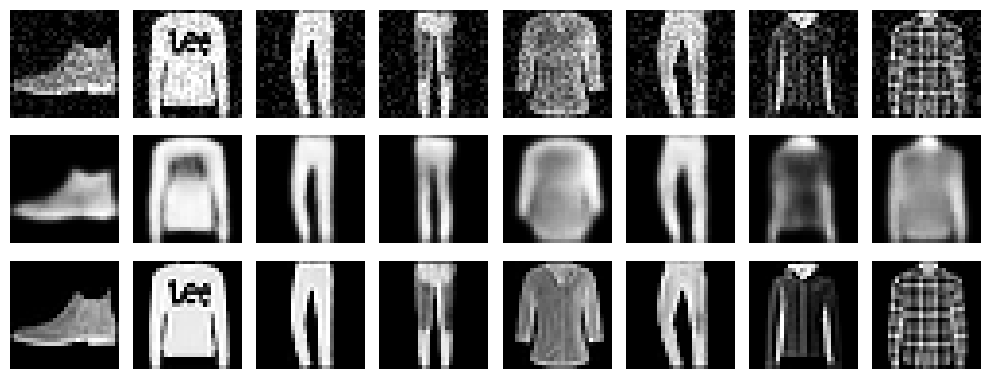

{'mse': 0.01224703248590231, 'ssim': 0.6745433211326599}


In [18]:
# inferencia en un pequeño lote
n = 8
recon = ae.predict(x_test_noisy[:n], verbose=0)

# visualización: ruidosa | reconstruida | original
plt.figure(figsize=(10, 4))
for i in range(n):
    # ruidosa
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
    # reconstruida
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(recon[i].squeeze(), cmap="gray")
    plt.axis("off")
    # original
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
plt.tight_layout()
plt.show()

# métricas globales
pred = ae.predict(x_test_noisy, verbose=0)
mse = np.mean((pred - x_test)**2)
ssim_vals = tf.image.ssim(tf.convert_to_tensor(pred), tf.convert_to_tensor(x_test), max_val=1.0)
ssim_mean = float(tf.reduce_mean(ssim_vals))
print({"mse": float(mse), "ssim": ssim_mean})

## Ejercicio 1: explorar capacidad y función de pérdida

1. Cambia `latent_dim` de 64 a 128 y reentrena.
2. Cambia la pérdida a `mse` y compara contra `binary_crossentropy`.
3. Registra una pequeña tabla con `latent_dim`, `pérdida_val`, `mse`, `ssim`.
**instrucciones:** completa los `todo` de la celda siguiente.


In [19]:
# TODO: establece latent_dim=128 y recompila el modelo
latent_dim = 256  # TODO: ajusta este valor como parte del ejercicio

# TODO: vuelve a definir encoder/decoder con el nuevo latent_dim (puedes reutilizar el bloque anterior)
inputs = keras.Input(shape=(28, 28, 1), name="entrada")
e = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
e = layers.MaxPooling2D()(e)
e = layers.Conv2D(64, 3, activation="relu", padding="same")(e)
e = layers.MaxPooling2D()(e)
e = layers.Flatten()(e)
z = layers.Dense(latent_dim, activation="relu", name="latente")(e)
d = layers.Dense(7*7*64, activation="relu")(z)
d = layers.Reshape((7, 7, 64))(d)
d = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(d)
d = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(d)
outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same", name="salida")(d)
ae2 = keras.Model(inputs, outputs, name="ae_denoising_latent128")

# TODO: cambia la pérdida a mse para comparar
ae2.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")  # TODO: prueba también "binary_crossentropy"
hist2 = ae2.fit(
    x_train_noisy, x_train,
    validation_data=(x_test_noisy, x_test),
    epochs=15, batch_size=128, verbose=1
)

pred2 = ae2.predict(x_test_noisy, verbose=0)
mse2 = np.mean((pred2 - x_test)**2)
ssim2 = float(tf.reduce_mean(tf.image.ssim(tf.convert_to_tensor(pred2), tf.convert_to_tensor(x_test), max_val=1.0)))
print({"mse": float(mse2), "ssim": ssim2})

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 135ms/step - loss: 0.0280 - val_loss: 0.0135
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 133ms/step - loss: 0.0116 - val_loss: 0.0104
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 133ms/step - loss: 0.0096 - val_loss: 0.0090
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 133ms/step - loss: 0.0085 - val_loss: 0.0082
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 133ms/step - loss: 0.0078 - val_loss: 0.0076
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 133ms/step - loss: 0.0073 - val_loss: 0.0072
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 133ms/step - loss: 0.0069 - val_loss: 0.0068
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 133ms/step - loss: 0.0066 - val_loss: 0.0066
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 133ms/step - loss: 0.0063 - val_loss: 0.0064
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 133ms/step - loss: 0.0061 - val_loss: 0.0062
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 132ms/step - loss: 0.0059 - val_loss: 0.0061
Epoch 12/15
469/469

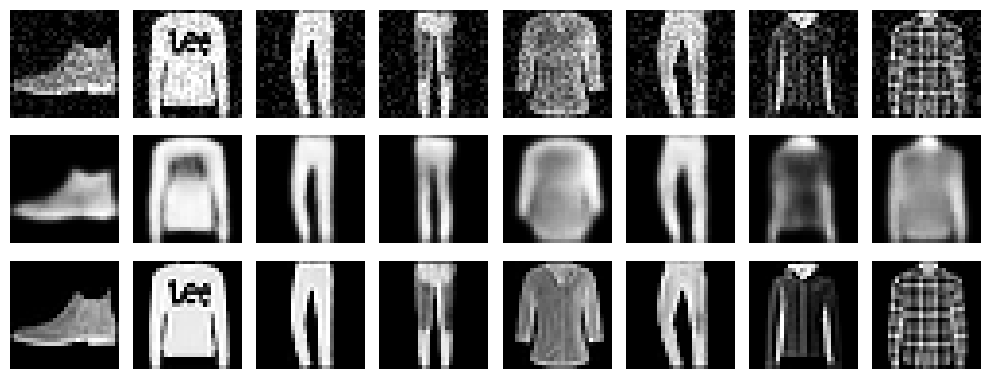

{'mse': 0.00562460720539093, 'ssim': 0.807525634765625}


In [20]:
# inferencia en un pequeño lote
n = 8
recon2 = ae2.predict(x_test_noisy[:n], verbose=0)

# visualización: ruidosa | reconstruida | original
plt.figure(figsize=(10, 4))
for i in range(n):
    # ruidosa
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
    # reconstruida

    plt.subplot(3, n, i + 1 + n)
    plt.imshow(recon[i].squeeze(), cmap="gray")
    plt.axis("off")

    # original
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
plt.tight_layout()
plt.show()

# métricas globales
pred2 = ae2.predict(x_test_noisy, verbose=0)
mse2 = np.mean((pred2 - x_test)**2)
ssim_vals2 = tf.image.ssim(tf.convert_to_tensor(pred2), tf.convert_to_tensor(x_test), max_val=1.0)
ssim_mean2 = float(tf.reduce_mean(ssim_vals2))
print({"mse": float(mse2), "ssim": ssim_mean2})

## Variational autoencoder (vae)
Ahora implementaremos un vae simple. El **encoder** producirá `mu` y `log_var`, y muestrearemos `z = mu + sigma * epsilon` (con `epsilon ~ n(0, i)`). La pérdida total es `recon + beta * kl`.


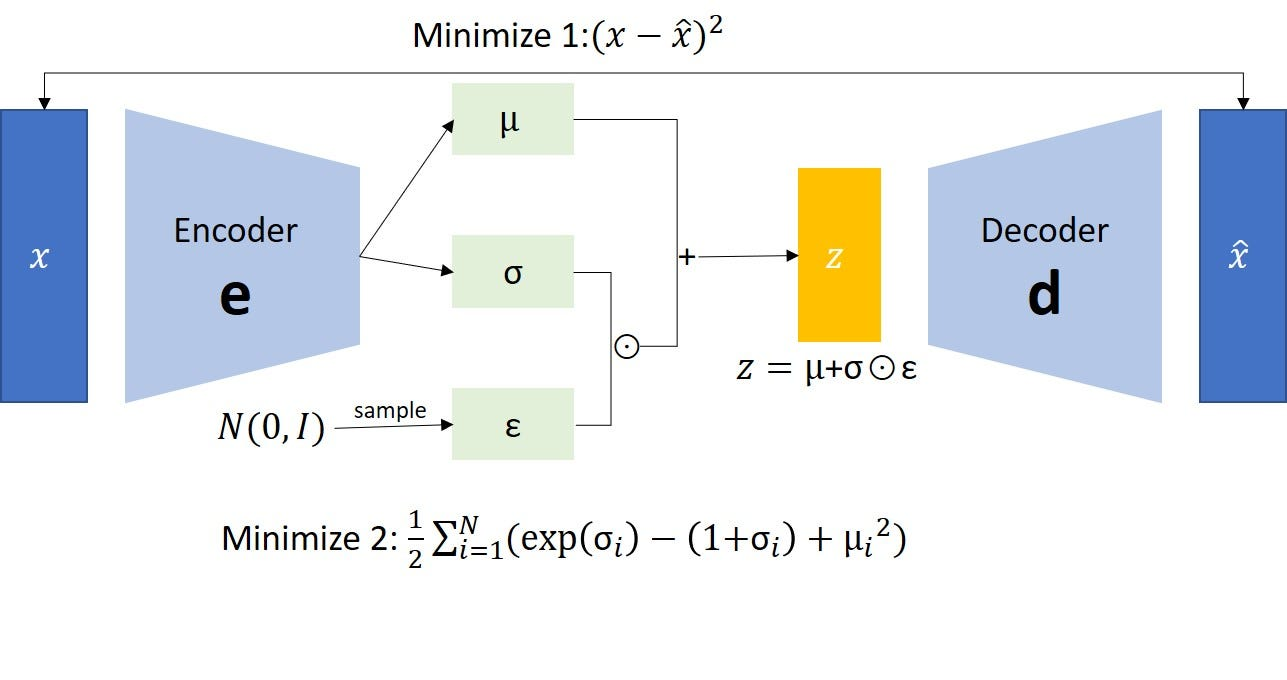

In [21]:

# celda a: encoder que devuelve mu, log_var y z
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

latent_dim = 16
beta = 1e-3

inputs = keras.Input(shape=(28, 28, 1), name="entrada")
e = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
e = layers.MaxPooling2D()(e)
e = layers.Conv2D(64, 3, activation="relu", padding="same")(e)
e = layers.MaxPooling2D()(e)
e = layers.Flatten()(e)
mu = layers.Dense(latent_dim, name="mu")(e)
log_var = layers.Dense(latent_dim, name="log_var")(e)

def sample_z(args):
    mu_, log_var_ = args
    eps = tf.random.normal(shape=tf.shape(mu_))
    return mu_ + tf.exp(0.5 * log_var_) * eps

z = layers.Lambda(sample_z, name="amostrado")([mu, log_var])
encoder = keras.Model(inputs, [mu, log_var, z], name="encoder")
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ entrada             │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28,    │        320 │ entrada[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 14, 14,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 14, 14,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 7, 7, 64)  │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 3136)      │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 16)        │     50,192 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 16)        │     50,192 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ amostrado (Lambda)  │ (None, 16)        │          0 │ mu[0][0],         │
│                     │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 119,200 (465.62 KB)

 Trainable params: 119,200 (465.62 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:

# celda b: decoder correcto (denso -> reshape -> deconvs)
z_in = keras.Input(shape=(latent_dim,), name="z_in")
x = layers.Dense(7*7*64, activation="relu", name="dec_dense")(z_in)
x = layers.Reshape((7, 7, 64), name="dec_reshape")(x)
x = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same", name="dec_deconv1")(x)
x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same", name="dec_deconv2")(x)
x_out = layers.Conv2D(1, 3, activation="sigmoid", padding="same", name="dec_out")(x)
decoder = keras.Model(z_in, x_out, name="decoder")

decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_in (InputLayer)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense (Dense)               │ (None, 3136)           │        53,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_reshape (Reshape)           │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv1 (Conv2DTranspose)   │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv2 (Conv2DTranspose)   │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_out (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,993 (425.75 KB)

 Trainable params: 108,993 (425.75 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:

# celda c: vae conectando encoder->decoder y entrenamiento/validación
(x_train, _), (x_test, _) = keras.datasets.fashion_mnist.load_data()
x_train = (x_train.astype("float32") / 255.0)[..., None]
x_test = (x_test.astype("float32") / 255.0)[..., None]

x_in = keras.Input(shape=(28, 28, 1), name="x_in")
mu_, log_var_, z_ = encoder(x_in)
x_recon = decoder(z_)
vae = keras.Model(x_in, x_recon, name="vae_simple")

mse_loss_fn = keras.losses.MeanSquaredError()
optimizer = keras.optimizers.Adam(1e-3)

@tf.function
def vae_loss(x_true, x_pred, mu_, log_var_):
    recon = mse_loss_fn(x_true, x_pred)
    kl = -0.5 * tf.reduce_mean(1 + log_var_ - tf.square(mu_) - tf.exp(log_var_))
    return recon + beta * kl, recon, kl

epochs = 15
batch_size = 256

train_ds = tf.data.Dataset.from_tensor_slices((x_train,)).batch(batch_size)
val_ds = tf.data.Dataset.from_tensor_slices((x_test,)).batch(batch_size)

train_hist, val_hist = [], []

for ep in range(epochs):
    # entrenamiento
    tr_losses = []
    for (xb,) in train_ds:
        with tf.GradientTape() as tape:
            mu_b, log_var_b, z_b = encoder(xb, training=True)
            recon_b = decoder(z_b, training=True)
            loss_b, recon_b_loss, kl_b = vae_loss(xb, recon_b, mu_b, log_var_b)
        grads = tape.gradient(loss_b, vae.trainable_weights)
        optimizer.apply_gradients(zip(grads, vae.trainable_weights))
        tr_losses.append(loss_b)

    # validación
    va_losses = []
    for (xb,) in val_ds:
        mu_b, log_var_b, z_b = encoder(xb, training=False)
        recon_b = decoder(z_b, training=False)
        loss_b, recon_b_loss, kl_b = vae_loss(xb, recon_b, mu_b, log_var_b)
        va_losses.append(loss_b)

    tr_mean = float(tf.reduce_mean(tr_losses))
    va_mean = float(tf.reduce_mean(va_losses))
    train_hist.append(tr_mean)
    val_hist.append(va_mean)

    if (ep + 1) % 5 == 0:
        print(f"época {ep+1:02d} | train={tr_mean:.4f} | val={va_mean:.4f} | beta={beta}")


2026-04-21 11:51:19.206710: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-21 11:51:22.432050: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-21 11:52:16.273791: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-21 11:54:10.166300: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


época 05 | train=0.0211 | val=0.0202 | beta=0.001


2026-04-21 11:58:01.829522: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


época 10 | train=0.0166 | val=0.0164 | beta=0.001
época 15 | train=0.0152 | val=0.0152 | beta=0.001


2026-04-21 12:05:49.022713: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


época 20 | train=0.0144 | val=0.0145 | beta=0.001
época 25 | train=0.0139 | val=0.0141 | beta=0.001
época 30 | train=0.0135 | val=0.0137 | beta=0.001


2026-04-21 12:21:34.465981: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


época 35 | train=0.0132 | val=0.0134 | beta=0.001
época 40 | train=0.0130 | val=0.0133 | beta=0.001
época 45 | train=0.0129 | val=0.0131 | beta=0.001
época 50 | train=0.0127 | val=0.0130 | beta=0.001


KeyboardInterrupt: 

In [ ]:
# celda d: curva de entrenamiento
plt.figure()
plt.plot(train_hist, label="train")
plt.plot(val_hist, label="val")
plt.xlabel("época")
plt.ylabel("pérdida total")
plt.legend()
plt.title("entrenamiento del vae (recon + beta*kl)")
plt.show()


In [ ]:

# celda e: generación de muestras
n = 16
z_samples = np.random.normal(size=(n, latent_dim)).astype("float32")
gen = decoder.predict(z_samples, verbose=0)

plt.figure(figsize=(6, 6))
for i in range(n):
    plt.subplot(4, 4, i + 1)
    plt.imshow(gen[i].squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle("muestras generadas por el vae")
plt.tight_layout()
plt.show()


## Ejercicio 2: barrido de beta e interpolaciones en el espacio latente
tarea:1. Cambia `beta` a `1e-2` y reentrena el vae (5 épocas). Registra la pérdida de validación.
2. Genera una fila de **interpolaciones** entre dos vectores `z` aleatorios (8 pasos). Comenta si las transiciones son suaves o abruptas.
**instrucciones:** completa los `todo` de la celda siguiente.


In [ ]:
# TODO: asigna un nuevo valor de beta y reentrena brevemente
beta = 1e-2  # TODO: prueba otros valores (p. ej., 5e-3, 2e-2)
print("beta actual:", beta)

# TODO: para simplificar, reusa el 'decoder' ya definido y asume que has reentrenado arriba con el nuevo beta
# interpolaciones entre dos puntos en z
z_a = np.random.normal(size=(latent_dim,)).astype("float32")
z_b = np.random.normal(size=(latent_dim,)).astype("float32")
steps = 8
alphas = np.linspace(0, 1, steps)
z_interp = np.array([(1 - a) * z_a + a * z_b for a in alphas]).astype("float32")
imgs = decoder.predict(z_interp, verbose=0)

plt.figure(figsize=(12, 2))
for i in range(steps):
    plt.subplot(1, steps, i + 1)
    plt.imshow(imgs[i].squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle("interpolaciones lineales en z")
plt.tight_layout()
plt.show()